# 02 — Threat and Distributional Baseline

## From spatial progression to statistical structure

This notebook estimates Expected Threat (xT) from the available match data and
uses the resulting pass-level value measures to examine the empirical structure
of attacking progression.

The analysis has two objectives:

1. estimate the attacking value associated with pitch locations and completed passes;
2. establish the distributional baseline required for later statistical inference.

Before selecting inferential models, the notebook therefore examines the observed
variables with respect to location, dispersion, distributional shape, extreme
observations, and between-match heterogeneity.

The resulting diagnostics are used to document which statistical assumptions appear
plausible and which require more robust or cluster-aware methods in later analysis.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [3]:
config_candidates = [
    Path("config.json"),
    Path("../config.json")
]

CONFIG_PATH = next(
    (path for path in config_candidates if path.exists()),
    None
)

if CONFIG_PATH is None:
    raise FileNotFoundError(
        "config.json was not found. "
        "Place it in the root of the repository."
    )

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

DATA_DIR = Path(config["statsbomb_data_dir"])

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"StatsBomb data directory not found: {DATA_DIR}"
    )

print("StatsBomb data directory loaded successfully.")

StatsBomb data directory loaded successfully.


In [4]:
REPO_DIR = CONFIG_PATH.resolve().parent
PROCESSED_DIR = REPO_DIR / "processed"

completed_path = PROCESSED_DIR / "completed_progressive_passes_prepared.csv"
main_path = PROCESSED_DIR / "main_passes_prepared.csv"

if not completed_path.exists() or not main_path.exists():
    raise FileNotFoundError(
        "Prepared datasets were not found. "
        "Run Notebook 01 first to create the processed data."
    )

completed_progressive_passes_df = pd.read_csv(completed_path)
main_passes_df = pd.read_csv(main_path)

print("Prepared datasets loaded successfully.")
print(f"Completed progressive passes: {len(completed_progressive_passes_df):,}")
print(f"Dynamic-possession passes: {len(main_passes_df):,}")

Prepared datasets loaded successfully.
Completed progressive passes: 2,412
Dynamic-possession passes: 19,397


In [5]:
data_overview = pd.DataFrame({
    "dataset": [
        "Dynamic-possession passes",
        "Completed progressive passes"
    ],
    "observations": [
        len(main_passes_df),
        len(completed_progressive_passes_df)
    ],
    "variables": [
        main_passes_df.shape[1],
        completed_progressive_passes_df.shape[1]
    ]
})

data_overview

,dataset,observations,variables
0,Dynamic-possession passes,19397,31
1,Completed progressive passes,2412,31


### Analytical datasets

`main_passes_df` contains the full dynamic-possession pass sample and therefore
preserves both completed and failed actions.

`completed_progressive_passes_df` contains successfully completed progressive
passes and is used when evaluating realized spatial transitions and attacking value.

The distinction is important: failure information is required for risk analysis,
whereas realized xT transitions require the ball to reach the destination state.

## 2. Data-Driven Expected Threat Model

To evaluate the attacking value of ball progression, an Expected Threat (xT)
model is estimated from the observed match actions.

The pitch is divided into a 12 × 8 grid, resulting in 96 spatial states.
Each state receives an xT value representing the estimated future attacking
value of possessing the ball in that area.

The model combines two ways in which possession can generate attacking value:

- taking a shot and generating expected goals;
- successfully moving the ball into another state from which future attacking
  value can be created.

Formally,

$$
xT(s)
=
P(\mathrm{shot} \mid s)
\, E[xG \mid \mathrm{shot}, s]
+
P(\mathrm{successful\ move} \mid s)
\sum_{s'}
P(s' \mid s, \mathrm{successful\ move})
\, xT(s').
$$

Failed movements do not generate continuation value because possession is no
longer assumed to remain with the attacking team.

The system is solved iteratively until the xT values converge.

The resulting xT surface provides a model-based value for each pitch state.
These state values are subsequently used to measure how individual completed
passes change the attacking value of possession.

In [6]:
COMPETITION_ID = 9
SEASON_ID = 281

matches_path = (
    DATA_DIR
    / "matches"
    / str(COMPETITION_ID)
    / f"{SEASON_ID}.json"
)

matches_df = pd.read_json(matches_path)

all_actions = []

for match_id in matches_df["match_id"]:
    events_path = DATA_DIR / "events" / f"{match_id}.json"
    events_df = pd.read_json(events_path)

    events_df["event_type"] = events_df["type"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    events_df["team_name"] = events_df["team"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    events_df["player_name"] = events_df["player"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    events_df["play_pattern_name"] = events_df["play_pattern"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    selected_events = events_df[
        events_df["event_type"].isin(["Pass", "Carry", "Shot"])
    ].copy()

    selected_events["match_id"] = match_id
    all_actions.append(selected_events)

actions_raw_df = pd.concat(all_actions, ignore_index=True)

action_overview = (
    actions_raw_df["event_type"]
    .value_counts()
    .rename_axis("action_type")
    .reset_index(name="observations")
)

action_overview

,action_type,observations
0,Pass,39214
1,Carry,32369
2,Shot,916


### 2.1 Action-Level Feature Construction

The raw event records contain spatial coordinates and action-specific information
inside nested StatsBomb fields.

For the xT model, each relevant action is transformed into a common analytical
representation containing:

- start location,
- end location for passes and carries,
- pass completion status,
- shot Expected Goals (xG),
- shot outcome.

This creates a consistent action-level dataset from which spatial states,
movement transitions, and shooting value can subsequently be estimated.

## At this stage, no distributional assumptions are imposed. The variables are constructed directly from the observed event data.

In [7]:
actions_df = actions_raw_df.copy()

# Start coordinates for all actions
actions_df["start_x"] = actions_df["location"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 2 else np.nan
)

actions_df["start_y"] = actions_df["location"].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) >= 2 else np.nan
)


# End coordinates depend on action type
def get_end_location(row):
    if row["event_type"] == "Pass":
        pass_data = row.get("pass")
        if isinstance(pass_data, dict):
            return pass_data.get("end_location")
        
    if row["event_type"] == "Carry":
        carry_data = row.get("carry")
        if isinstance(carry_data, dict):
            return carry_data.get("end_location")
        
    return None


actions_df["end_location"] = actions_df.apply(get_end_location, axis=1)

actions_df["end_x"] = actions_df["end_location"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 2 else np.nan
)

actions_df["end_y"] = actions_df["end_location"].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) >= 2 else np.nan
)


# Pass success
actions_df["pass_outcome"] = actions_df["pass"].apply(
    lambda x: x.get("outcome", {}).get("name") if isinstance(x, dict) and isinstance(x.get("outcome"), dict) else None
)

actions_df["pass_success"] = np.where(
    actions_df["event_type"] == "Pass",
    actions_df["pass_outcome"].isna(),
    np.nan
)


# Shot xG and goal outcome
actions_df["statsbomb_xg"] = actions_df["shot"].apply(
    lambda x: x.get("statsbomb_xg") if isinstance(x, dict) else np.nan
)

actions_df["shot_outcome"] = actions_df["shot"].apply(
    lambda x: x.get("outcome", {}).get("name") if isinstance(x, dict) and isinstance(x.get("outcome"), dict) else None
)

actions_df["is_goal"] = actions_df["shot_outcome"] == "Goal"


actions_df = actions_df[
    [
        "match_id",
        "team_name",
        "player_name",
        "event_type",
        "play_pattern_name",
        "start_x",
        "start_y",
        "end_x",
        "end_y",
        "pass_success",
        "pass_outcome",
        "statsbomb_xg",
        "shot_outcome",
        "is_goal"
    ]
].copy()

actions_df.head()

,match_id,team_name,player_name,event_type,play_pattern_name,start_x,start_y,end_x,end_y,pass_success,pass_outcome,statsbomb_xg,shot_outcome,is_goal
0,3895292,Union Berlin,Brenden Aaronson,Pass,From Kick Off,61.0,40.1,58.5,38.9,1.0,NaN,NaN,NaN,False
1,3895292,Union Berlin,András Schäfer,Pass,From Kick Off,58.8,38.6,35.9,50.9,1.0,NaN,NaN,NaN,False
2,3895292,Union Berlin,Danilho Doekhi,Carry,From Kick Off,35.9,50.9,37.9,52.2,NaN,NaN,NaN,NaN,False
3,3895292,Union Berlin,Danilho Doekhi,Pass,From Kick Off,37.9,52.2,86.1,6.0,1.0,NaN,NaN,NaN,False
4,3895292,Union Berlin,Robin Gosens,Pass,From Kick Off,84.3,6.2,94.2,16.7,0.0,Incomplete,NaN,NaN,False


### 2.2 Analytical Scope for xT Estimation

The xT model is estimated on the same dynamic-possession scope used in
Notebook 01.

The included play patterns are:

- Regular Play
- From Counter
- From Keeper
- Other

Set-piece phases such as corners, free kicks, throw-ins, goal kicks, and kick-offs
are excluded because they represent structurally different possession situations.

The unit of observation at this stage is an individual football action
(pass, carry, or shot) occurring within the available 34-match sample.

Importantly, these actions should not yet be interpreted as independent and
identically distributed observations. Multiple actions occur within the same match
and team context. This dependence will be examined explicitly before inferential
models are introduced.

In [8]:
dynamic_play_patterns = [
    "Regular Play",
    "From Counter",
    "From Keeper",
    "Other"
]

actions_model_df = actions_df[
    actions_df["play_pattern_name"].isin(dynamic_play_patterns)
].copy()

model_scope_summary = (
    actions_model_df["event_type"]
    .value_counts()
    .rename_axis("action_type")
    .reset_index(name="observations")
)

model_scope_summary

,action_type,observations
0,Pass,19397
1,Carry,17498
2,Shot,384


### 2.3 Movement Attempts, Successful Transitions, and Shots

The xT model distinguishes between three related concepts:

- **movement attempts**: passes and carries initiated from a spatial state,
- **successful movement transitions**: movements that actually transfer the ball
  to another observed state,
- **shots**: actions that convert the current state directly into a scoring attempt.

Failed passes are retained as movement attempts but are not treated as successful
state transitions. This distinction prevents unsuccessful actions from disappearing
from the empirical action structure.

Carries are treated as realized movements because the recorded event contains an
observed start and end location.

In [9]:
movement_attempts_df = actions_model_df[
    actions_model_df["event_type"].isin(["Pass", "Carry"])
].copy()

successful_movement_actions_df = movement_attempts_df[
    (
        (movement_attempts_df["event_type"] == "Pass")
        & (movement_attempts_df["pass_success"] == True)
    )
    |
    (movement_attempts_df["event_type"] == "Carry")
].copy()

shot_actions_df = actions_model_df[
    actions_model_df["event_type"] == "Shot"
].copy()

movement_summary = pd.DataFrame({
    "action_group": [
        "Movement attempts",
        "Successful movement transitions",
        "Shots"
    ],
    "observations": [
        len(movement_attempts_df),
        len(successful_movement_actions_df),
        len(shot_actions_df)
    ]
})

movement_summary

,action_group,observations
0,Movement attempts,36895
1,Successful movement transitions,34446
2,Shots,384


### 2.4 Empirical Action Structure

Before estimating spatial transition probabilities, the observed action sample is
summarized explicitly.

This distinction is important because the xT model uses different denominators:

- all movement attempts describe how often possession is moved from a state,
- successful movements determine observed transitions between states,
- shots determine the shooting component of state value.

The counts below therefore document the empirical quantities from which the
subsequent probability estimates are constructed.

In [10]:
action_structure_summary = pd.DataFrame({
    "quantity": [
        "All actions in xT scope",
        "Movement attempts",
        "Successful movement transitions",
        "Failed movement attempts",
        "Shots"
    ],
    "observations": [
        len(actions_model_df),
        len(movement_attempts_df),
        len(successful_movement_actions_df),
        len(movement_attempts_df) - len(successful_movement_actions_df),
        len(shot_actions_df)
    ]
})

action_structure_summary

,quantity,observations
0,All actions in xT scope,37279
1,Movement attempts,36895
2,Successful movement transitions,34446
3,Failed movement attempts,2449
4,Shots,384


### 2.5 Spatial State Definition

Expected Threat is modeled as a state-value problem. A state \(s\) represents
the location of the ball on the pitch.

The StatsBomb pitch coordinates span:

- \(x \in [0,120]\)
- \(y \in [0,80]\)

The pitch is partitioned into a **12 × 8 grid**, producing 96 spatial states.
Each cell therefore covers approximately \(10 \times 10\) coordinate units.

For movement actions, both the starting state \(s\) and destination state \(s'\)
are required. For shots, only the starting state is required.

The grid converts continuous pitch coordinates into a finite discrete state
space on which transition probabilities and state values can be estimated.

In [11]:
XT_COLS = 12
XT_ROWS = 8

PITCH_LENGTH = 120
PITCH_WIDTH = 80

CELL_WIDTH = PITCH_LENGTH / XT_COLS
CELL_HEIGHT = PITCH_WIDTH / XT_ROWS


def add_start_xt_grid(df):
    df = df.copy()

    df["start_xT_col"] = np.floor(
        df["start_x"] / CELL_WIDTH
    ).astype(int)

    df["start_xT_row"] = np.floor(
        df["start_y"] / CELL_HEIGHT
    ).astype(int)

    df["start_xT_col"] = df["start_xT_col"].clip(
        0, XT_COLS - 1
    )

    df["start_xT_row"] = df["start_xT_row"].clip(
        0, XT_ROWS - 1
    )

    df["start_xT_zone"] = (
        df["start_xT_col"].astype(str)
        + "_"
        + df["start_xT_row"].astype(str)
    )

    return df


def add_start_end_xt_grid(df):
    df = add_start_xt_grid(df)

    df["end_xT_col"] = np.floor(
        df["end_x"] / CELL_WIDTH
    ).astype(int)

    df["end_xT_row"] = np.floor(
        df["end_y"] / CELL_HEIGHT
    ).astype(int)

    df["end_xT_col"] = df["end_xT_col"].clip(
        0, XT_COLS - 1
    )

    df["end_xT_row"] = df["end_xT_row"].clip(
        0, XT_ROWS - 1
    )

    df["end_xT_zone"] = (
        df["end_xT_col"].astype(str)
        + "_"
        + df["end_xT_row"].astype(str)
    )

    return df

In [12]:
movement_attempts_df = add_start_xt_grid(
    movement_attempts_df
)

successful_movement_actions_df = add_start_end_xt_grid(
    successful_movement_actions_df
)

shot_actions_df = add_start_xt_grid(
    shot_actions_df
)

print(f"Spatial states: {XT_COLS * XT_ROWS}")
print(f"Cell dimensions: {CELL_WIDTH:.0f} × {CELL_HEIGHT:.0f}")

Spatial states: 96
Cell dimensions: 10 × 10


### 2.6 Empirical Action Probabilities by State

For each spatial state \(s\), the observed actions are divided into three
mutually exclusive outcomes:

1. a shot is taken,
2. a movement is completed successfully,
3. a movement attempt fails.

The corresponding probabilities are estimated empirically from the observed
frequencies within each state.

**Shot probability**

$$
\widehat{P}(\mathrm{shot}\mid s)
=
\frac{N_{\mathrm{shot},s}}
     {N_{\mathrm{all},s}}
$$

**Successful-movement probability**

$$
\widehat{P}(\mathrm{success}\mid s)
=
\frac{N_{\mathrm{success},s}}
     {N_{\mathrm{all},s}}
$$

**Failed-movement probability**

$$
\widehat{P}(\mathrm{failure}\mid s)
=
\frac{N_{\mathrm{failure},s}}
     {N_{\mathrm{all},s}}
$$

where

$$
N_{\mathrm{all},s}
=
N_{\mathrm{shot},s}
+
N_{\mathrm{success},s}
+
N_{\mathrm{failure},s}.
$$

Therefore, for every observed state,

$$
\widehat{P}(\mathrm{shot}\mid s)
+
\widehat{P}(\mathrm{success}\mid s)
+
\widehat{P}(\mathrm{failure}\mid s)
=
1.
$$

A failed movement receives no future possession value in the xT recursion.
It therefore enters the model through its probability of terminating the
current attacking transition rather than through a destination state.

In [13]:
# Number of movement attempts starting in each state
movement_attempt_counts = (
    movement_attempts_df
    .groupby(["start_xT_row", "start_xT_col"])
    .size()
    .rename("movement_attempts")
)

# Number of successful movements starting in each state
successful_move_counts = (
    successful_movement_actions_df
    .groupby(["start_xT_row", "start_xT_col"])
    .size()
    .rename("successful_moves")
)

# Number of shots starting in each state
shot_counts = (
    shot_actions_df
    .groupby(["start_xT_row", "start_xT_col"])
    .size()
    .rename("shots")
)

# Combine counts for all 96 spatial states
state_index = pd.MultiIndex.from_product(
    [range(XT_ROWS), range(XT_COLS)],
    names=["start_xT_row", "start_xT_col"]
)

state_action_summary = pd.DataFrame(index=state_index)

state_action_summary = state_action_summary.join(
    movement_attempt_counts
).join(
    successful_move_counts
).join(
    shot_counts
).fillna(0)

state_action_summary["failed_moves"] = (
    state_action_summary["movement_attempts"]
    - state_action_summary["successful_moves"]
)

state_action_summary["all_actions"] = (
    state_action_summary["movement_attempts"]
    + state_action_summary["shots"]
)

state_action_summary["p_shot"] = (
    state_action_summary["shots"]
    / state_action_summary["all_actions"]
)

state_action_summary["p_successful_move"] = (
    state_action_summary["successful_moves"]
    / state_action_summary["all_actions"]
)

state_action_summary["p_failed_move"] = (
    state_action_summary["failed_moves"]
    / state_action_summary["all_actions"]
)

state_action_summary.head(12)

movement_attempts  successful_moves  shots  \
start_xT_row start_xT_col                                               
0            0                            67                46    0.0   
             1                           138               117    0.0   
             2                           253               223    0.0   
             3                           319               289    0.0   
             4                           464               428    0.0   
             5                           426               397    0.0   
             6                           505               478    0.0   
             7                           549               523    0.0   
             8                           442               418    0.0   
             9                           389               363    0.0   
             10                          179               163    0.0   
             11                           72                49    0.0   

                           failed_moves  all_actions  p_shot  \
start_xT_row start_xT_col                                      
0            0                       21         67.0     0.0   
             1                       21        138.0     0.0   
             2                       30        253.0     0.0   
             3                       30        319.0     0.0   
             4                       36        464.0     0.0   
             5                       29        426.0     0.0   
             6                       27        505.0     0.0   
             7                       26        549.0     0.0   
             8                       24        442.0     0.0   
             9                       26        389.0     0.0   
             10                      16        179.0     0.0   
             11                      23         72.0     0.0   

                           p_successful_move  p_failed_move  
start_xT_row start_xT_col                                    
0            0                      0.686567       0.313433  
             1                      0.847826       0.152174  
             2                      0.881423       0.118577  
             3                      0.905956       0.094044  
             4                      0.922414       0.077586  
             5                      0.931925       0.068075  
             6                      0.946535       0.053465  
             7                      0.952641       0.047359  
             8                      0.945701       0.054299  
             9                      0.933162       0.066838  
             10                     0.910615       0.089385  
             11                     0.680556       0.319444

In [14]:
probability_sum = (
    state_action_summary["p_shot"]
    + state_action_summary["p_successful_move"]
    + state_action_summary["p_failed_move"]
)

observed_states = state_action_summary["all_actions"] > 0

print(
    "Observed states:",
    observed_states.sum(),
    "of",
    XT_ROWS * XT_COLS
)

print(
    "Probability sums valid:",
    np.allclose(
        probability_sum[observed_states],
        1.0
    )
)

Observed states: 96 of 96
Probability sums valid: True


### 2.7 Shot Value by State

The shooting component of the xT model requires an estimate of the value of a
shot taken from each spatial state.

Rather than estimating scoring probability only from the observed goals in the
34-match sample, the analysis uses the StatsBomb Expected Goals (`xG`) value
attached to each shot.

For a state \(s\), the state-level shot value is estimated as the mean xG of all
shots observed from that state:

$$
\widehat{xG}(s)
=
\frac{1}{N_{\mathrm{shot},s}}
\sum_{i=1}^{N_{\mathrm{shot},s}} xG_i.
$$

This is an empirical aggregation of an externally provided shot-quality model:
the individual xG values are not estimated from the present sample, but their
state-level average is.

States without an observed shot receive a shot value of zero in the current
grid-based model.

In [15]:
shot_value_by_state = (
    shot_actions_df
    .groupby(["start_xT_row", "start_xT_col"])["statsbomb_xg"]
    .agg(
        number_of_shots="count",
        mean_xg="mean",
        median_xg="median",
        sd_xg="std"
    )
)

state_action_summary = state_action_summary.join(
    shot_value_by_state
)

state_action_summary["mean_xg"] = (
    state_action_summary["mean_xg"]
    .fillna(0)
)

state_action_summary[
    [
        "shots",
        "p_shot",
        "mean_xg"
    ]
].head(12)

shots  p_shot  mean_xg
start_xT_row start_xT_col                        
0            0               0.0     0.0      0.0
             1               0.0     0.0      0.0
             2               0.0     0.0      0.0
             3               0.0     0.0      0.0
             4               0.0     0.0      0.0
             5               0.0     0.0      0.0
             6               0.0     0.0      0.0
             7               0.0     0.0      0.0
             8               0.0     0.0      0.0
             9               0.0     0.0      0.0
             10              0.0     0.0      0.0
             11              0.0     0.0      0.0

### 2.8 Successful Movement Transition Matrix

The previous sections estimated how often an action from state \(s\) results in
a shot, a successful movement, or a failed movement.

For a successful movement, the model additionally requires the destination state
\(s'\).

The conditional transition probability is estimated as

$$
\widehat{P}(S'=s' \mid S=s,\text{ successful move})
=
\frac{N_{s\rightarrow s'}}
     {N_{\text{successful move},s}}.
$$

The resulting transition matrix contains one row for every starting state and one
column for every destination state.

With 96 spatial states, the matrix therefore has dimension

$$
96 \times 96.
$$

For a state containing at least one successful movement, the probabilities across
all possible destination states should sum to one.

This matrix describes **where possession moves conditional on the movement being
successful**. The probability that a movement succeeds is modeled separately by
\(\widehat{P}(\text{successful move}\mid s)\).

In [16]:
N_STATES = XT_ROWS * XT_COLS

successful_movement_actions_df["start_state_id"] = (
    successful_movement_actions_df["start_xT_row"] * XT_COLS
    + successful_movement_actions_df["start_xT_col"]
)

successful_movement_actions_df["end_state_id"] = (
    successful_movement_actions_df["end_xT_row"] * XT_COLS
    + successful_movement_actions_df["end_xT_col"]
)

transition_counts = pd.crosstab(
    successful_movement_actions_df["start_state_id"],
    successful_movement_actions_df["end_state_id"]
).reindex(
    index=range(N_STATES),
    columns=range(N_STATES),
    fill_value=0
)

transition_matrix = transition_counts.to_numpy(dtype=float)

row_totals = transition_matrix.sum(axis=1, keepdims=True)

transition_matrix = np.divide(
    transition_matrix,
    row_totals,
    out=np.zeros_like(transition_matrix),
    where=row_totals != 0
)

print("Transition matrix shape:", transition_matrix.shape)

Transition matrix shape: (96, 96)


In [17]:
transition_row_sums = transition_matrix.sum(axis=1)

states_with_successful_moves = (
    transition_counts.sum(axis=1).to_numpy() > 0
)

print(
    "States with successful movements:",
    states_with_successful_moves.sum()
)

print(
    "Transition probabilities valid:",
    np.allclose(
        transition_row_sums[states_with_successful_moves],
        1.0
    )
)

States with successful movements: 96
Transition probabilities valid: True


### 2.9 Iterative Expected Threat Estimation

The previous steps provide all empirical components required for the xT model:

- the probability of taking a shot from state \(s\),
- the expected shot value in state \(s\),
- the probability of completing a movement from state \(s\),
- the conditional distribution of destination states after a successful movement.

The immediate shooting value of a state is

$$
r(s)
=
\widehat{P}(\mathrm{shot}\mid s)
\cdot
\widehat{xG}(s).
$$

Expected Threat additionally includes the future value that can be reached through
successful ball movement:

$$
xT(s)
=
r(s)
+
\widehat{P}(\mathrm{successful\ move}\mid s)
\sum_{s'}
\widehat{P}(s'\mid s,\mathrm{successful\ move})
xT(s').
$$

Failed movements have continuation value zero because possession is not retained.

The equation is solved iteratively. Starting from zero future value, each iteration
propagates attacking value backwards through the observed movement transitions until
the state values converge.

In [18]:
# State-level model components
p_shot = state_action_summary["p_shot"].to_numpy()
p_successful_move = (
    state_action_summary["p_successful_move"].to_numpy()
)
mean_xg = state_action_summary["mean_xg"].to_numpy()

# Immediate shooting value
shot_threat = p_shot * mean_xg

# Start with no future continuation value
xt = np.zeros(N_STATES)

saved_iterations = {}

MAX_ITERATIONS = 500
TOLERANCE = 1e-6

for iteration in range(1, MAX_ITERATIONS + 1):

    future_movement_value = transition_matrix @ xt

    xt_new = (
        shot_threat
        + p_successful_move * future_movement_value
    )

    if iteration in [1, 2, 4]:
        saved_iterations[iteration] = xt_new.copy()

    max_change = np.max(np.abs(xt_new - xt))

    xt = xt_new

    if max_change < TOLERANCE:
        break

saved_iterations["final"] = xt.copy()

print("Iterations until convergence:", iteration)
print("Maximum final change:", f"{max_change:.2e}")
print("Minimum xT:", f"{xt.min():.6f}")
print("Maximum xT:", f"{xt.max():.6f}")

Iterations until convergence: 87
Maximum final change: 9.76e-07
Minimum xT: 0.006032
Maximum xT: 0.268801


### 2.10 Fixed-Point Validation

The iterative procedure should converge to a solution of the xT fixed-point equation

$$
xT = r + QxT,
$$

where \(r\) is the immediate shooting value and \(QxT\) represents the expected
continuation value of successful movements.

After convergence, the residual

$$
r + QxT - xT
$$

should therefore be close to zero for every spatial state.

In [19]:
fixed_point_update = (
    shot_threat
    + p_successful_move * (transition_matrix @ xt)
)

fixed_point_residual = fixed_point_update - xt

print(
    "Maximum absolute fixed-point residual:",
    f"{np.max(np.abs(fixed_point_residual)):.2e}"
)

print(
    "Mean absolute fixed-point residual:",
    f"{np.mean(np.abs(fixed_point_residual)):.2e}"
)

Maximum absolute fixed-point residual: 8.80e-07
Mean absolute fixed-point residual: 4.82e-07


### 2.11 Final Expected Threat Surface

The converged xT vector contains one estimated state value for each of the
96 spatial states.

The values are now mapped back to their corresponding pitch locations and combined
with the empirical state-level model components.

The resulting table represents the final estimated Expected Threat surface used
for all subsequent pass-level value calculations.

In [20]:
final_xt_df = (
    state_action_summary
    .reset_index()
    .copy()
)

final_xt_df["state_id"] = (
    final_xt_df["start_xT_row"] * XT_COLS
    + final_xt_df["start_xT_col"]
)

xt_lookup = pd.Series(
    xt,
    index=range(N_STATES)
)

final_xt_df["xT"] = (
    final_xt_df["state_id"]
    .map(xt_lookup)
)

final_xt_df = final_xt_df[
    [
        "state_id",
        "start_xT_row",
        "start_xT_col",
        "all_actions",
        "p_shot",
        "mean_xg",
        "p_successful_move",
        "p_failed_move",
        "xT"
    ]
].sort_values("state_id")

final_xt_df.head(12)

,state_id,start_xT_row,start_xT_col,all_actions,p_shot,mean_xg,p_successful_move,p_failed_move,xT
0,0,0,0,67.0,0.0,0.0,0.686567,0.313433,0.006032
1,1,0,1,138.0,0.0,0.0,0.847826,0.152174,0.009808
2,2,0,2,253.0,0.0,0.0,0.881423,0.118577,0.011359
3,3,0,3,319.0,0.0,0.0,0.905956,0.094044,0.013810
4,4,0,4,464.0,0.0,0.0,0.922414,0.077586,0.016510
5,5,0,5,426.0,0.0,0.0,0.931925,0.068075,0.019506
6,6,0,6,505.0,0.0,0.0,0.946535,0.053465,0.022687
7,7,0,7,549.0,0.0,0.0,0.952641,0.047359,0.026721
8,8,0,8,442.0,0.0,0.0,0.945701,0.054299,0.030038
9,9,0,9,389.0,0.0,0.0,0.933162,0.066838,0.032856


In [21]:
import matplotlib.pyplot as plt

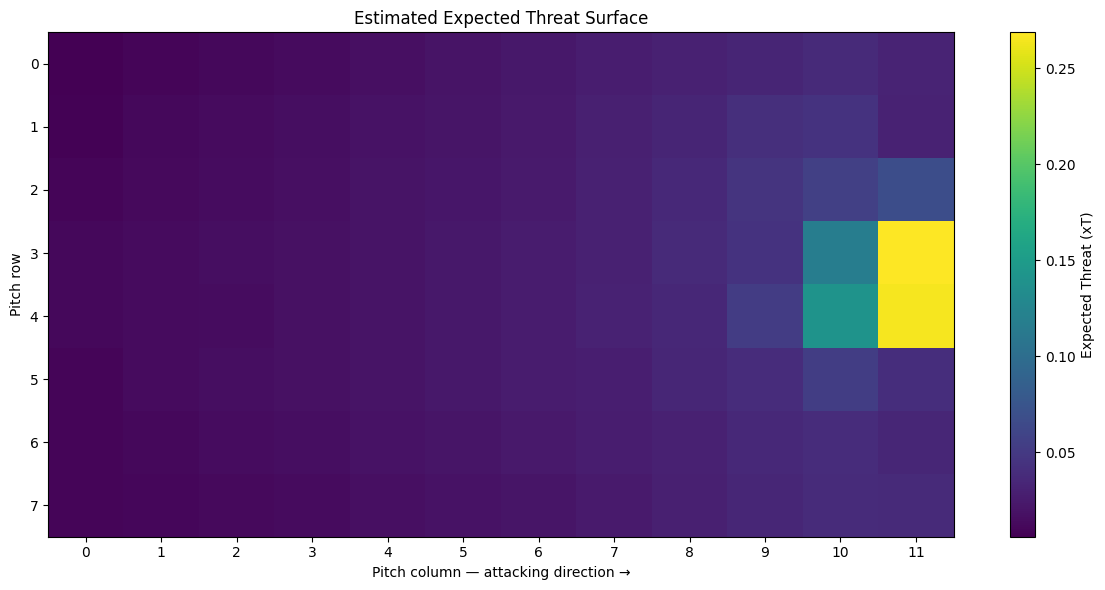

In [22]:
xt_grid = (
    final_xt_df
    .pivot(
        index="start_xT_row",
        columns="start_xT_col",
        values="xT"
    )
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(12, 6))

image = ax.imshow(
    xt_grid,
    origin="upper",
    aspect="auto"
)

colorbar = plt.colorbar(
    image,
    ax=ax
)

colorbar.set_label("Expected Threat (xT)")

ax.set_title(
    "Estimated Expected Threat Surface"
)

ax.set_xlabel(
    "Pitch column — attacking direction →"
)

ax.set_ylabel(
    "Pitch row"
)

ax.set_xticks(range(XT_COLS))
ax.set_yticks(range(XT_ROWS))

plt.tight_layout()
plt.show()

In [23]:
xt_lookup_df = final_xt_df[
    [
        "start_xT_row",
        "start_xT_col",
        "xT"
    ]
].copy()

xt_lookup_df["xT_zone"] = (
    xt_lookup_df["start_xT_col"].astype(str)
    + "_"
    + xt_lookup_df["start_xT_row"].astype(str)
)

xt_lookup_df = xt_lookup_df[
    ["xT_zone", "xT"]
]

xt_lookup_df.head()

,xT_zone,xT
0,0_0,0.006032
1,1_0,0.009808
2,2_0,0.011359
3,3_0,0.013810
4,4_0,0.016510


## 3. From State Values to Pass-Level Attacking Value

The xT model assigns an estimated attacking value to each of the 96 spatial
states on the pitch.

To evaluate individual passes, these state values are mapped back to completed
dynamic-possession pass events.

For a completed pass starting in state \(s\) and ending in state \(s'\), the
pass-level change in estimated attacking value is defined as

\[
\Delta xT
=
xT(s') - xT(s).
\]

A positive \(\Delta xT\) means that the pass moves possession to a state with
higher estimated attacking value. A negative value means that possession is
moved to a state with lower estimated attacking value.

This quantity should be interpreted as a **model-based change in attacking
state value**, not as a causal effect of the pass or as the realised probability
of scoring from that individual action.

### Completion and Value Are Treated Separately

Pass-level \(\Delta xT\) is evaluated only for successfully completed passes,
because only completed passes reach the observed destination state used in the
xT calculation.

Failed pass attempts are therefore not assigned the intended destination's xT
value.

Instead, the analysis separates two questions:

1. **Value conditional on successful completion:**  
   How much attacking value does a completed pass create?

2. **Execution reliability:**  
   How likely is the pass to be completed?

The first question is analysed using completed passes and their \(\Delta xT\)
values. The second is analysed separately using all pass attempts.

Both progressive and non-progressive passes are retained so that attacking
reward and execution risk can later be compared within a common analytical
framework.

In [24]:
# Keep completed dynamic-possession passes
completed_main_xt_df = main_passes_df[
    main_passes_df["pass_success"]
].copy()

# Map pass coordinates to the same 12 × 8 spatial grid
completed_main_xt_df = add_start_end_xt_grid(
    completed_main_xt_df
)

# Convert grid positions into the same state IDs used by the xT model
completed_main_xt_df["start_state_id"] = (
    completed_main_xt_df["start_xT_row"] * XT_COLS
    + completed_main_xt_df["start_xT_col"]
)

completed_main_xt_df["end_state_id"] = (
    completed_main_xt_df["end_xT_row"] * XT_COLS
    + completed_main_xt_df["end_xT_col"]
)

# Assign xT values directly from the final state-value vector
completed_main_xt_df["xT_start"] = xt[
    completed_main_xt_df["start_state_id"].to_numpy()
]

completed_main_xt_df["xT_end"] = xt[
    completed_main_xt_df["end_state_id"].to_numpy()
]

# Realized change in Expected Threat
completed_main_xt_df["delta_xT"] = (
    completed_main_xt_df["xT_end"]
    - completed_main_xt_df["xT_start"]
)

print(
    "Completed dynamic-possession passes:",
    len(completed_main_xt_df)
)

Completed dynamic-possession passes: 16948


In [25]:
pass_value_validation = pd.DataFrame({
    "check": [
        "Completed passes",
        "Missing start state",
        "Missing end state",
        "Missing xT start",
        "Missing xT end",
        "Missing delta xT"
    ],
    "value": [
        len(completed_main_xt_df),
        completed_main_xt_df["start_state_id"].isna().sum(),
        completed_main_xt_df["end_state_id"].isna().sum(),
        completed_main_xt_df["xT_start"].isna().sum(),
        completed_main_xt_df["xT_end"].isna().sum(),
        completed_main_xt_df["delta_xT"].isna().sum()
    ]
})

pass_value_validation

,check,value
0,Completed passes,16948
1,Missing start state,0
2,Missing end state,0
3,Missing xT start,0
4,Missing xT end,0
5,Missing delta xT,0


### 3.1 Progressive and Non-Progressive Pass Groups

The completed-pass dataset is now separated according to the progressive-pass
definition established in Notebook 01.

This distinction is used only as an analytical grouping variable.

The comparison does not yet constitute a statistical test. At this stage, the
goal is to preserve the two groups so that their empirical distributions can
later be examined before inferential assumptions are introduced.

In [26]:
if "is_progressive_attempt" not in completed_main_xt_df.columns:
    raise KeyError(
        "The variable 'is_progressive_attempt' is missing. "
        "Check the output of Notebook 01."
    )

completed_main_xt_df["progression_group"] = np.where(
    completed_main_xt_df["is_progressive_attempt"],
    "Progressive",
    "Non-progressive"
)

progression_counts = (
    completed_main_xt_df["progression_group"]
    .value_counts()
    .rename_axis("progression_group")
    .reset_index(name="completed_passes")
)

progression_counts

,progression_group,completed_passes
0,Non-progressive,14536
1,Progressive,2412


In [27]:
n_progressive_completed = (
    completed_main_xt_df["is_progressive_attempt"]
    .sum()
)

print(
    "Completed progressive passes in Notebook 02:",
    n_progressive_completed
)

print(
    "Completed progressive passes from Notebook 01:",
    len(completed_progressive_passes_df)
)

print(
    "Counts consistent:",
    n_progressive_completed
    == len(completed_progressive_passes_df)
)

Completed progressive passes in Notebook 02: 2412
Completed progressive passes from Notebook 01: 2412
Counts consistent: True


## 4. Distributional Baseline

The xT model provides a pass-level measure of realized attacking value,
$\Delta xT$, for all completed dynamic-possession passes.

Before selecting probability models, confidence intervals, or hypothesis tests,
the empirical structure of the relevant variables is examined.

The statistical workflow is:

$$
\text{data}
\rightarrow
\text{empirical distribution}
\rightarrow
\text{distributional assumptions}
\rightarrow
\text{estimation and uncertainty}
\rightarrow
\text{inference}
$$

An important distinction is maintained throughout the analysis:

- the **empirical distribution of the observed pass values**, and
- the **sampling distribution of an estimator**

are not the same object.

The first variable examined is pass-level $\Delta xT$.

### 4.1 Statistical Variable Definition: Pass-Level Delta xT

For every completed dynamic-possession pass $i$, define the random variable

$$
X_i
=
\Delta xT_i
=
xT_{\text{end},i}
-
xT_{\text{start},i}.
$$

The observational unit is one completed dynamic-possession pass.

The observed value can be:

- **positive**, if the pass moves possession to a state with higher xT;
- **zero**, if the start and destination states have equal xT;
- **negative**, if the destination state has lower xT.

Because the xT model is defined on a finite $12 \times 8$ grid, the possible
values of $\Delta xT$ arise from differences between a finite collection of
estimated state values.

Therefore, $\Delta xT$ should not automatically be treated as an arbitrary
continuous variable with a prespecified theoretical distribution.

At this stage, no Normal, Gamma, or other parametric distribution is assumed.

The empirical distribution is examined first.

In [28]:
delta_xt_audit = pd.DataFrame({
    "quantity": [
        "Observations",
        "Missing values",
        "Non-missing values",
        "Unique values"
    ],
    "value": [
        len(completed_main_xt_df),
        completed_main_xt_df["delta_xT"].isna().sum(),
        completed_main_xt_df["delta_xT"].notna().sum(),
        completed_main_xt_df["delta_xT"].nunique()
    ]
})

delta_xt_audit

,quantity,value
0,Observations,16948
1,Missing values,0
2,Non-missing values,16948
3,Unique values,2628


### 4.2 Location and Dispersion of Delta xT

The empirical distribution of pass-level $\Delta xT$ is first summarized using
measures of location and dispersion.

For the observed values

$$
X_1, X_2, \ldots, X_n,
$$

the analysis reports:

- the sample mean,
- the sample variance,
- the sample standard deviation,
- the median,
- the first and third quartiles,
- the interquartile range,
- the minimum and maximum.

The mean and median describe different aspects of location. The variance,
standard deviation, and interquartile range quantify different aspects of
dispersion.

At this stage, these are descriptive sample statistics. No theoretical
distribution for $\Delta xT$ is assumed.

In [29]:
delta_xt = (
    completed_main_xt_df["delta_xT"]
    .dropna()
)

q1 = delta_xt.quantile(0.25)
q3 = delta_xt.quantile(0.75)

delta_xt_summary = pd.DataFrame({
    "statistic": [
        "n",
        "mean",
        "sample variance",
        "sample standard deviation",
        "minimum",
        "Q1",
        "median",
        "Q3",
        "maximum",
        "IQR"
    ],
    "value": [
        delta_xt.size,
        delta_xt.mean(),
        delta_xt.var(ddof=1),
        delta_xt.std(ddof=1),
        delta_xt.min(),
        q1,
        delta_xt.median(),
        q3,
        delta_xt.max(),
        q3 - q1
    ]
})

delta_xt_summary

,statistic,value
0,n,16948.000000
1,mean,0.002079
2,sample variance,0.000254
3,sample standard deviation,0.015935
4,minimum,-0.229325
5,Q1,-0.001952
6,median,0.000549
7,Q3,0.003177
8,maximum,0.238303
9,IQR,0.005129


### 4.3 Empirical Distribution Shape of Delta xT

The numerical summary suggests that most completed passes produce relatively small
changes in Expected Threat, while a smaller number of observations reach much more
extreme positive or negative values.

In addition, the sample mean is larger than the median, which may indicate an
asymmetric distribution.

These observations are only preliminary.

The empirical shape of the distribution is therefore examined visually before any
parametric probability model is considered.

The first diagnostic is a histogram of pass-level $\Delta xT$.
The sample mean and median are added as reference points.

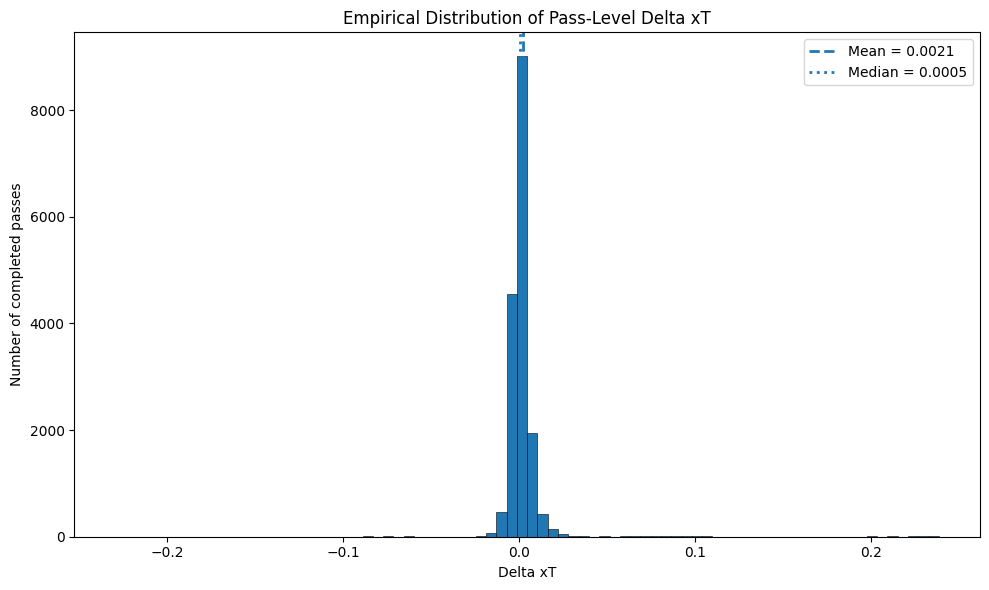

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    delta_xt,
    bins=80,
    edgecolor="black",
    linewidth=0.4
)

ax.axvline(
    delta_xt.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {delta_xt.mean():.4f}"
)

ax.axvline(
    delta_xt.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {delta_xt.median():.4f}"
)

ax.set_title(
    "Empirical Distribution of Pass-Level Delta xT"
)

ax.set_xlabel(
    "Delta xT"
)

ax.set_ylabel(
    "Number of completed passes"
)

ax.legend()

plt.tight_layout()
plt.show()

### 4.4 Central Distribution of Delta xT

The full-range histogram reveals the complete range of observed values, but the
extreme tails compress the region in which most observations are concentrated.

To examine the local structure around zero, the same empirical distribution is
therefore displayed over a restricted x-axis range.

This is a visualization choice only. No observations are removed from the dataset,
and all subsequent numerical analyses continue to use the complete sample.

The purpose of the zoomed view is to examine whether the central distribution is
approximately symmetric, strongly peaked, skewed, or characterized by additional
local structure.

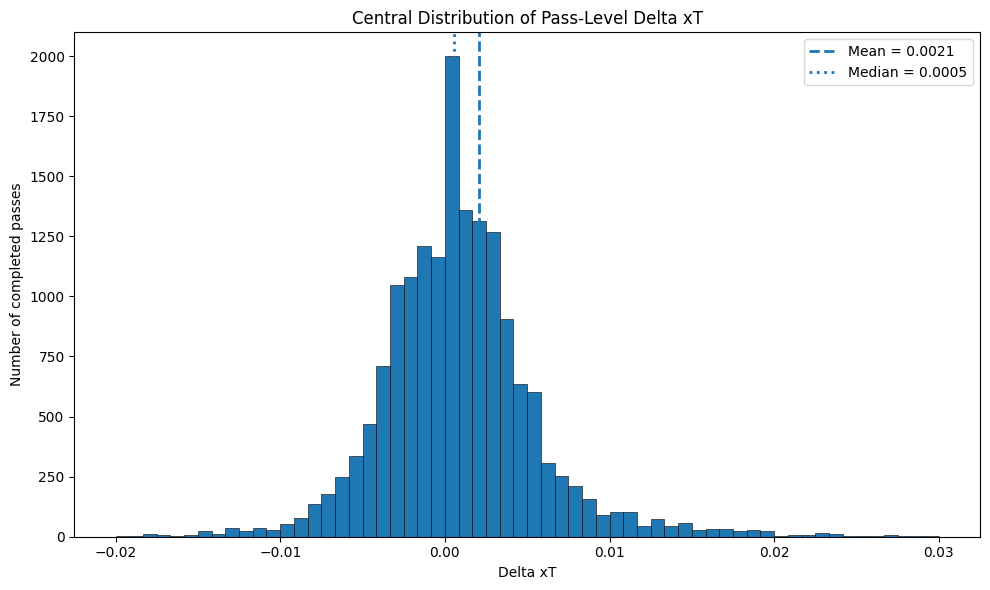

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    delta_xt,
    bins=60,
    range=(-0.02, 0.03),
    edgecolor="black",
    linewidth=0.4
)

ax.axvline(
    delta_xt.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {delta_xt.mean():.4f}"
)

ax.axvline(
    delta_xt.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {delta_xt.median():.4f}"
)

ax.set_title(
    "Central Distribution of Pass-Level Delta xT"
)

ax.set_xlabel("Delta xT")
ax.set_ylabel("Number of completed passes")

ax.legend()

plt.tight_layout()
plt.show()

### 4.5 Direction of Threat Change

The histogram shows a strong concentration of observations around zero.

To quantify this structure, completed passes are classified according to whether
they decrease, preserve, or increase Expected Threat.

This provides a direct descriptive interpretation of the sign of pass-level
$\Delta xT$ before the full empirical distribution is examined further.

In [32]:
delta_xt_direction = pd.DataFrame({
    "category": [
        "Negative Delta xT",
        "Zero Delta xT",
        "Positive Delta xT"
    ],
    "observations": [
        (delta_xt < 0).sum(),
        (delta_xt == 0).sum(),
        (delta_xt > 0).sum()
    ]
})

delta_xt_direction["percentage"] = (
    delta_xt_direction["observations"]
    / len(delta_xt)
    * 100
)

delta_xt_direction

,category,observations,percentage
0,Negative Delta xT,6959,41.060892
1,Zero Delta xT,898,5.298560
2,Positive Delta xT,9091,53.640548


#### Interpretation

Among completed dynamic-possession passes, 53.64% increase Expected Threat,
41.06% decrease Expected Threat, and 5.30% leave the estimated threat value
unchanged.

Thus, pass completion alone does not imply positive attacking value:
a substantial share of successfully completed passes move possession to states
with lower estimated xT.

The sign classification describes the **direction** of threat change but not its
**magnitude**. A very small positive change and a very large positive change are
both classified as positive.

The proportion of observations with $\Delta xT \leq 0$ is approximately 46.36%,
which is consistent with the slightly positive sample median observed previously.

### 4.6 Empirical Cumulative Distribution Function

The previous analysis classified passes according to the sign of $\Delta xT$.

A more general description is provided by the empirical cumulative distribution
function (ECDF),

$$
\widehat F_n(x)
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbf{1}(X_i \leq x).
$$

For any threshold $x$, the ECDF gives the observed proportion of completed passes
with $\Delta xT$ less than or equal to that threshold.

Unlike the histogram, the ECDF does not depend on the choice of histogram bins.
It therefore provides a complementary view of the complete empirical distribution.

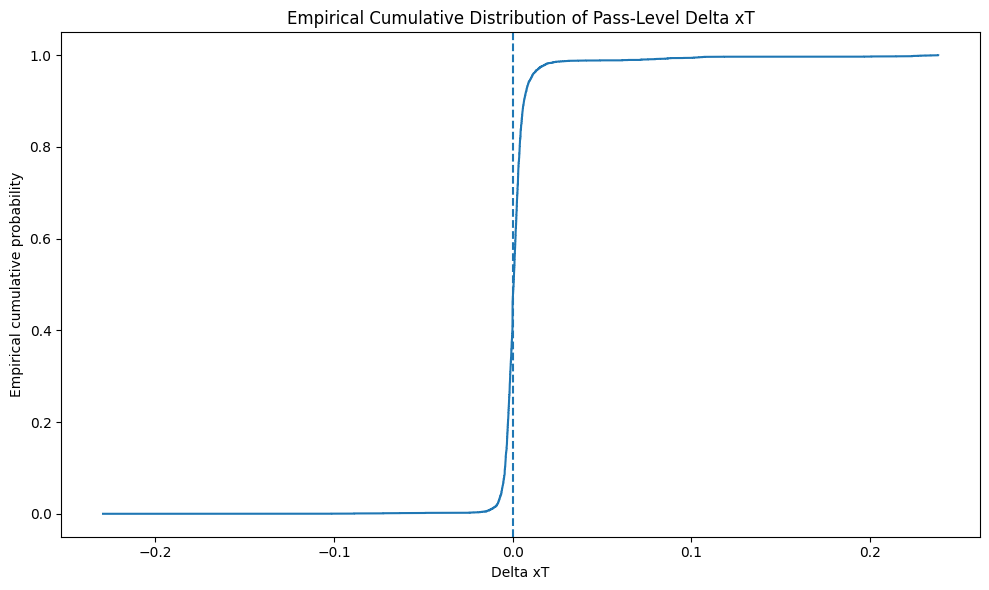

In [33]:
delta_xt_sorted = np.sort(
    delta_xt.to_numpy()
)

ecdf = (
    np.arange(1, len(delta_xt_sorted) + 1)
    / len(delta_xt_sorted)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.step(
    delta_xt_sorted,
    ecdf,
    where="post"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Empirical Cumulative Distribution of Pass-Level Delta xT"
)

ax.set_xlabel("Delta xT")
ax.set_ylabel("Empirical cumulative probability")

plt.tight_layout()
plt.show()

The ECDF shows that pass-level attacking value is strongly concentrated around zero. Most completed passes produce only small changes in Expected Threat, while large positive and negative changes occur relatively rarely. This indicates that pass completion alone provides limited information about attacking contribution and motivates a closer examination of the pass types associated with the higher-value part of the distribution.

### 4.7 Boxplot and IQR-Based Tail Diagnostics

The histogram and ECDF indicate that most pass-level $\Delta xT$ values are
concentrated close to zero, while a smaller number of observations extend much
further into the tails.

A boxplot provides a complementary view based on the median, quartiles, and
interquartile range.

The conventional IQR fences are defined as

$$
L = Q_1 - 1.5\,IQR
$$

and

$$
U = Q_3 + 1.5\,IQR.
$$

Observations outside these fences are flagged as unusually distant relative to
the central 50% of the empirical distribution.

Such observations are not automatically data errors and are not removed from
the analysis. The purpose is to quantify the tail structure of the observed
distribution.

In [34]:
lower_fence = q1 - 1.5 * (q3 - q1)
upper_fence = q3 + 1.5 * (q3 - q1)

lower_tail_count = (delta_xt < lower_fence).sum()
upper_tail_count = (delta_xt > upper_fence).sum()

iqr_tail_summary = pd.DataFrame({
    "quantity": [
        "Lower IQR fence",
        "Upper IQR fence",
        "Observations below lower fence",
        "Observations above upper fence",
        "Total observations outside fences",
        "Percentage outside fences"
    ],
    "value": [
        lower_fence,
        upper_fence,
        lower_tail_count,
        upper_tail_count,
        lower_tail_count + upper_tail_count,
        (
            (lower_tail_count + upper_tail_count)
            / len(delta_xt)
            * 100
        )
    ]
})

iqr_tail_summary

,quantity,value
0,Lower IQR fence,-0.009645
1,Upper IQR fence,0.010870
2,Observations below lower fence,265.000000
3,Observations above upper fence,779.000000
4,Total observations outside fences,1044.000000
5,Percentage outside fences,6.160019


Most completed passes generate relatively small changes in attacking value, but a non-negligible minority produces substantially larger changes. These unusually large changes occur much more frequently on the positive side than on the negative side, suggesting that a small subset of passes is responsible for disproportionately large attacking gains.

#### Interpretation

Using the conventional \(1.5 \times IQR\) rule, 1,044 completed passes
(6.16% of the sample) fall outside the central IQR-based fences.

The tail structure is asymmetric:

- 265 passes (1.56%) fall below the lower fence,
- 779 passes (4.60%) exceed the upper fence.

Thus, unusually large positive changes in Expected Threat occur substantially
more often than unusually large negative changes.

This result supports the previous evidence of positive skewness in the
distribution.

Observations outside the IQR fences are not interpreted as data errors and are
not removed automatically. Instead, they represent passes whose threat changes
are unusually large relative to the central distribution and may be tactically
important.

### 4.8 Boxplot of Pass-Level Delta xT

The IQR-based diagnostics showed that 6.16% of completed passes lie outside the
conventional \(1.5 \times IQR\) fences, with substantially more observations in
the upper than in the lower tail.

The boxplot visualizes this structure by displaying:

- the first quartile \(Q_1\),
- the median,
- the third quartile \(Q_3\),
- the whiskers defined by the conventional IQR rule,
- and observations beyond those whiskers.

Points beyond the whiskers are interpreted as observations that are unusually
distant relative to the central distribution. They are not automatically treated
as errors and are not removed from the dataset.

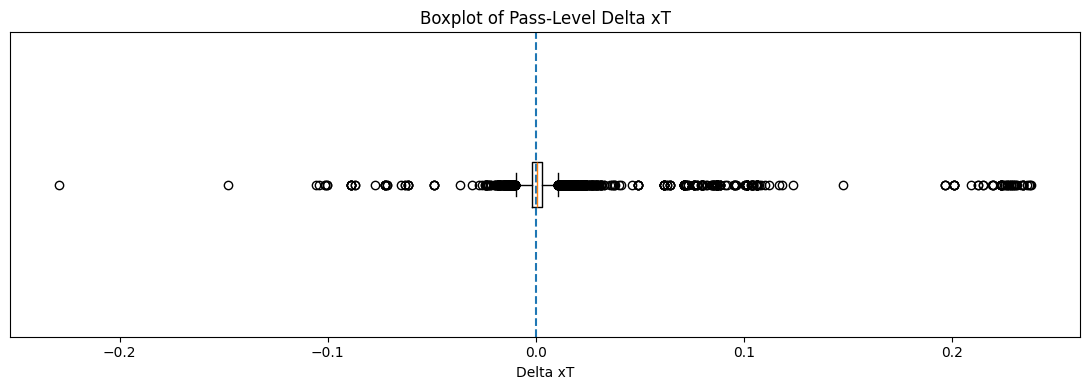

In [35]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.boxplot(
    delta_xt,
    vert=False,
    showfliers=True
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Boxplot of Pass-Level Delta xT"
)

ax.set_xlabel(
    "Delta xT"
)

ax.set_yticks([])

plt.tight_layout()
plt.show()

#### Interpretation

The boxplot confirms a highly concentrated central distribution combined with
substantially longer tails.

The middle 50% of completed passes occupy a very narrow range around zero,
whereas a smaller set of observations extends much further in both directions.

The upper tail is substantially more populated than the lower tail:

- 779 observations lie above the upper IQR fence,
- 265 observations lie below the lower IQR fence.

Thus, unusually large positive changes in Expected Threat occur almost three
times as often as unusually large negative changes.

The points beyond the whiskers are not interpreted as errors. They represent
passes with unusually large threat changes relative to the central distribution
and may therefore be tactically important.

### 4.9 Skewness and Tail Shape

The previous diagnostics consistently indicate an asymmetric distribution:

- the sample mean exceeds the median,
- the upper IQR tail contains substantially more observations than the lower tail,
- and the histogram and boxplot suggest a longer positive tail.

To quantify this asymmetry, the sample skewness of pass-level $\Delta xT$ is now
calculated.

Skewness summarizes the direction and strength of distributional asymmetry:

- values close to zero indicate approximate symmetry,
- positive values indicate a longer or heavier right tail,
- negative values indicate a longer or heavier left tail.

Excess kurtosis is also reported as a descriptive measure of tail concentration
relative to a Normal distribution.

These statistics are used descriptively and do not themselves establish a
particular theoretical distribution.

In [36]:
delta_xt_shape_summary = pd.DataFrame({
    "statistic": [
        "Sample skewness",
        "Excess kurtosis",
        "Upper-to-lower IQR-tail ratio"
    ],
    "value": [
        delta_xt.skew(),
        delta_xt.kurt(),
        upper_tail_count / lower_tail_count
    ]
})

delta_xt_shape_summary

,statistic,value
0,Sample skewness,9.031894
1,Excess kurtosis,123.204554
2,Upper-to-lower IQR-tail ratio,2.939623


#### Interpretation

The distribution of pass-level $\Delta xT$ is strongly asymmetric.

The sample skewness of 9.03 confirms a pronounced positive skew:
most completed passes generate relatively small changes in Expected Threat,
while a much smaller number of passes produce substantially larger positive
changes.

The excess kurtosis of 123.20 indicates that the empirical distribution differs
strongly from the shape of a Normal distribution. In this dataset, the distribution
combines a very concentrated central region with relatively distant observations
in the tails.

The upper-to-lower IQR-tail ratio of 2.94 further shows that unusually large
positive threat changes occur almost three times as often as unusually large
negative changes.

Taken together, these diagnostics indicate that the sample mean alone is not an
adequate description of pass-level attacking value. Median, quantiles, the ECDF,
and tail behavior remain important for subsequent comparisons.

These results do not imply that only the positive tail should be analyzed.
The complete distribution — negative, near-zero, and positive threat changes —
remains relevant.

### Statistical Decision Framework

The empirical distribution of pass-level $\Delta xT$ is strongly asymmetric,
highly concentrated around zero, and contains both negative and positive values.

Because $\Delta xT$ is constructed as the difference between start-state and
end-state xT values on a finite 12 × 8 grid, repeated values and bounded support
are structural consequences of the xT representation used in this analysis.

The exploratory distributional analysis therefore does not motivate the
assumption of a simple parametric family for raw $\Delta xT$.

In particular:

- a Normal distribution is not imposed on the individual $\Delta xT$
  observations because the empirical distribution is strongly asymmetric;
- Gamma and Lognormal distributions are not appropriate for the raw variable
  because $\Delta xT$ can take negative values;
- the empirical distribution, its quantiles, and its ECDF are therefore retained
  as the primary description of the distributional shape.

The purpose of this distributional analysis is not to determine automatically
whether the mean or median should be used. Instead, the estimand is determined
by the analytical question, while the observed distribution determines how that
estimand should be interpreted and which additional summaries and uncertainty
methods are required.

#### Estimands and Estimators

Let $G$ denote the progression group, where $G=P$ indicates a progressive pass
and $G=N$ a non-progressive pass. Let $C=1$ denote successful pass completion.

The primary reward estimand for group $g$ is the expected pass-level threat
change among successfully completed passes,

$$
\mu_g
=
E[\Delta xT \mid G=g,\ C=1].
$$

The corresponding empirical estimator is the pass-weighted sample mean,

$$
\hat{\mu}_g
=
\frac{1}{n_g}
\sum_{i:G_i=g,\ C_i=1}
\Delta xT_i.
$$

The sample mean is used here because the estimand itself is an expectation:
the analytical question concerns expected realized attacking reward per
completed action.

Its use does **not** imply that the raw $\Delta xT$ observations are assumed
to follow a Normal distribution.

The strong asymmetry observed in the empirical distribution does, however,
mean that the sample mean should not be interpreted as describing a
"typical" completed pass.

A second distributional estimand is therefore the conditional median,

$$
m_g
=
\operatorname{Med}(\Delta xT \mid G=g,\ C=1).
$$

The mean and median answer different questions:

- $\mu_g$ describes expected attacking reward per completed action;
- $m_g$ describes the central location of the completed-pass distribution.

The median is therefore not treated as a replacement for the mean. Instead,
it complements the mean by showing whether expected reward is representative
of the central mass of the distribution or is influenced substantially by
relatively rare high-value actions.

For the same reason, empirical quartiles, the ECDF, and the proportions of
negative, zero, and positive $\Delta xT$ values are retained as additional
distributional summaries.

For pass completion, the estimand for group $g$ is the conditional completion
probability,

$$
p_g
=
P(C=1 \mid G=g).
$$

Because completion is binary, with

$$
C_i =
\begin{cases}
1, & \text{if the pass is completed},\\
0, & \text{if the pass fails},
\end{cases}
$$

the empirical estimator of $p_g$ is the sample completion proportion,

$$
\hat{p}_g
=
\frac{1}{N_g}
\sum_{i:G_i=g} C_i.
$$

The two primary reward-risk contrasts are therefore

$$
\Delta_{\mathrm{reward}}
=
\mu_P-\mu_N
$$

and

$$
\Delta_{\mathrm{completion}}
=
p_P-p_N.
$$

Their empirical estimators are

$$
\widehat{\Delta}_{\mathrm{reward}}
=
\hat{\mu}_P-\hat{\mu}_N
$$

and

$$
\widehat{\Delta}_{\mathrm{completion}}
=
\hat{p}_P-\hat{p}_N.
$$

The first contrast compares expected realized attacking value conditional on
successful completion. The second compares execution success probabilities.

These two quantities describe different components of the reward-risk problem
and should therefore not be collapsed into a single net-value measure at this
stage.

#### Estimator Properties and Scope

The estimators above are empirical estimators of distributional functionals.

No claim is made that they are uniformly minimum-variance unbiased (UMVU) or
efficient estimators under a particular parametric family, because no such
parametric family is imposed on the raw pass-level $\Delta xT$ distribution.

In particular:

- $\mu_g$ and $p_g$ are descriptive functionals of the corresponding observed
  conditional distributions;
- no low-dimensional sufficient statistic for the full nonparametric
  distribution is assumed;
- finite-sample unbiasedness under the clustered match structure is not claimed;
- efficiency and UMVU optimality are not established;
- consistency for a broader population would require assumptions about the
  sampling of matches and the dependence structure between match clusters.

The descriptive parameters above are identified from their corresponding
observed conditional distributions within the analytical sample. They should
not be interpreted as causal effects of making a pass progressive.

In particular,

$$
E[\Delta xT \mid G=P,\ C=1]
-
E[\Delta xT \mid G=N,\ C=1]
$$

is an observational contrast between two groups of completed passes, not the
effect that would necessarily result from intervening and changing a
non-progressive pass into a progressive one.

The distributional analysis performed above therefore serves several purposes.

It shows that:

1. no simple parametric model for raw $\Delta xT$ is justified by the observed
   distribution without additional assumptions;
2. the mean alone is insufficient for describing the distribution because the
   central mass and the upper tail behave very differently;
3. median, empirical quantiles, and the ECDF provide complementary information
   about the location and shape of the distribution;
4. repeated values are partly structural consequences of the finite xT grid;
5. uncertainty estimation should not rely naively on an iid Normal model for
   the individual pass observations.

#### Dependence Structure and Uncertainty

Pass observations are not naturally interpreted as mutually independent
sampling units.

Passes within the same match share contextual conditions such as opponent,
team tactics, game state, and match-specific patterns. Treating all pass events
as iid observations would therefore ignore an important source of dependence.

The uncertainty analysis consequently treats the match as the resampling
cluster.

Instead of resampling individual passes, the match-cluster bootstrap resamples
entire matches with replacement while retaining all pass observations belonging
to each selected match.

For every bootstrap sample, the same estimators are recalculated:

$$
\widehat{\Delta}_{\mathrm{reward}}^{*(b)}
=
\hat{\mu}_P^{*(b)}
-
\hat{\mu}_N^{*(b)}
$$

and

$$
\widehat{\Delta}_{\mathrm{completion}}^{*(b)}
=
\hat{p}_P^{*(b)}
-
\hat{p}_N^{*(b)}.
$$

The bootstrap therefore does not define new estimators. Its purpose is to
approximate the sampling variability of the existing estimators while
preserving the dependence structure of passes within matches.

The resulting bootstrap intervals quantify uncertainty with respect to
variation across the observed match clusters.

They should not be interpreted as establishing league-wide population effects,
because the available 34 matches are not assumed to constitute a random
representative sample of the entire Bundesliga population.

### 4.10 Progressive vs. Non-Progressive Completed Passes

The overall distribution of pass-level $\Delta xT$ is strongly concentrated
around zero, positively skewed, and characterized by asymmetric tails.

The next question is whether this distribution differs between progressive and
non-progressive passes.

This comparison is conducted first among **completed passes only**.

Therefore, the analysis describes

$$
\text{realized attacking value conditional on pass completion},
$$

rather than the probability that a pass is completed.

For each progression group, the analysis compares:

- sample size,
- mean and median $\Delta xT$,
- standard deviation,
- first and third quartiles,
- interquartile range,
- the proportions of negative, zero, and positive $\Delta xT$ values.

No inferential test is performed at this stage.
The empirical distributions are compared descriptively first.

In [37]:
def summarize_delta_xt_group(group):
    x = group["delta_xT"].dropna()

    q1_group = x.quantile(0.25)
    q3_group = x.quantile(0.75)

    return pd.Series({
        "n": len(x),
        "mean_delta_xT": x.mean(),
        "median_delta_xT": x.median(),
        "sd_delta_xT": x.std(ddof=1),
        "Q1": q1_group,
        "Q3": q3_group,
        "IQR": q3_group - q1_group,
        "negative_pct": (x < 0).mean() * 100,
        "zero_pct": (x == 0).mean() * 100,
        "positive_pct": (x > 0).mean() * 100
    })


progression_distribution_summary = (
    completed_main_xt_df
    .groupby("progression_group")
    .apply(summarize_delta_xt_group)
)

progression_distribution_summary

,n,mean_delta_xT,median_delta_xT,sd_delta_xT,Q1,Q3,IQR,negative_pct,zero_pct,positive_pct
progression_group,,,,,,,,,,
Non-progressive,14536.0,0.001321,0.000000,0.016496,-0.002383,0.002298,0.004682,47.406439,6.177766,46.415795
Progressive,2412.0,0.006644,0.004917,0.010960,0.002752,0.007871,0.005119,2.819237,0.000000,97.180763


#### Decision Insight

Completed progressive passes show a substantially stronger attacking-value
profile than completed non-progressive passes in this sample.

- 97.18% of completed progressive passes increase Expected Threat,
  compared with 46.42% of non-progressive passes.
- The median $\Delta xT$ of progressive passes is 0.00492,
  while the median for non-progressive passes is approximately zero.
- Even the first quartile of the progressive-pass distribution is positive
  ($Q_1 = 0.00275$).

This suggests that the difference is not driven only by a small number of
extreme high-value passes. The central part of the progressive-pass
distribution is also shifted toward positive attacking value.

However, this comparison is conditional on pass completion.
It does not yet account for the higher execution risk associated with
progressive passing.

The next analytical question is therefore:

> **Does the additional attacking value of progressive passing compensate
> for its lower probability of successful completion?**

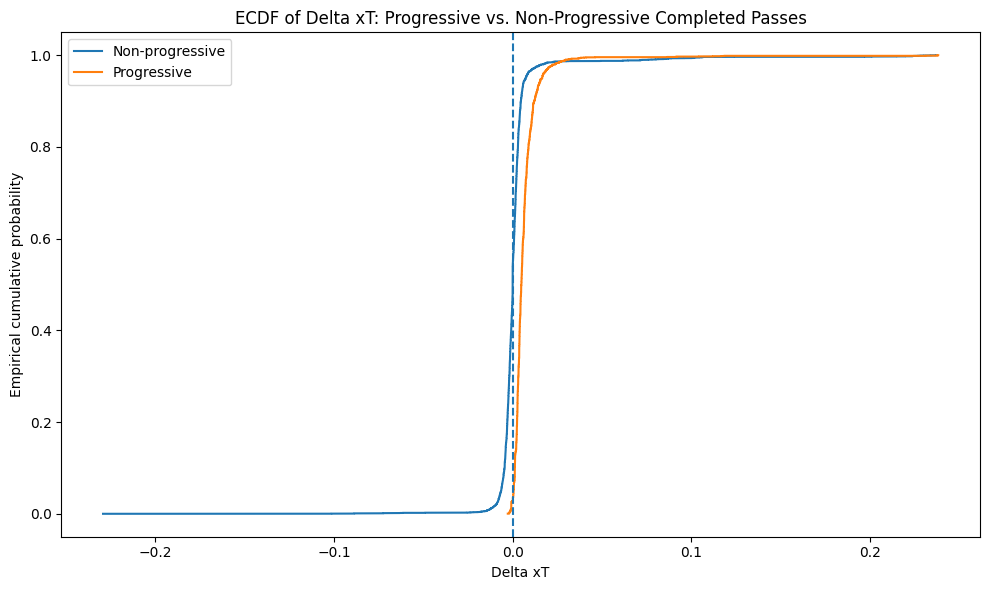

In [38]:
progressive_delta_xt = (
    completed_main_xt_df.loc[
        completed_main_xt_df["progression_group"] == "Progressive",
        "delta_xT"
    ]
    .dropna()
    .to_numpy()
)

non_progressive_delta_xt = (
    completed_main_xt_df.loc[
        completed_main_xt_df["progression_group"] == "Non-progressive",
        "delta_xT"
    ]
    .dropna()
    .to_numpy()
)


def empirical_cdf(values):
    values_sorted = np.sort(values)

    probabilities = (
        np.arange(1, len(values_sorted) + 1)
        / len(values_sorted)
    )

    return values_sorted, probabilities


progressive_x, progressive_ecdf = empirical_cdf(
    progressive_delta_xt
)

non_progressive_x, non_progressive_ecdf = empirical_cdf(
    non_progressive_delta_xt
)


fig, ax = plt.subplots(figsize=(10, 6))

ax.step(
    non_progressive_x,
    non_progressive_ecdf,
    where="post",
    label="Non-progressive"
)

ax.step(
    progressive_x,
    progressive_ecdf,
    where="post",
    label="Progressive"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "ECDF of Delta xT: Progressive vs. Non-Progressive Completed Passes"
)

ax.set_xlabel("Delta xT")
ax.set_ylabel("Empirical cumulative probability")

ax.legend()

plt.tight_layout()
plt.show()

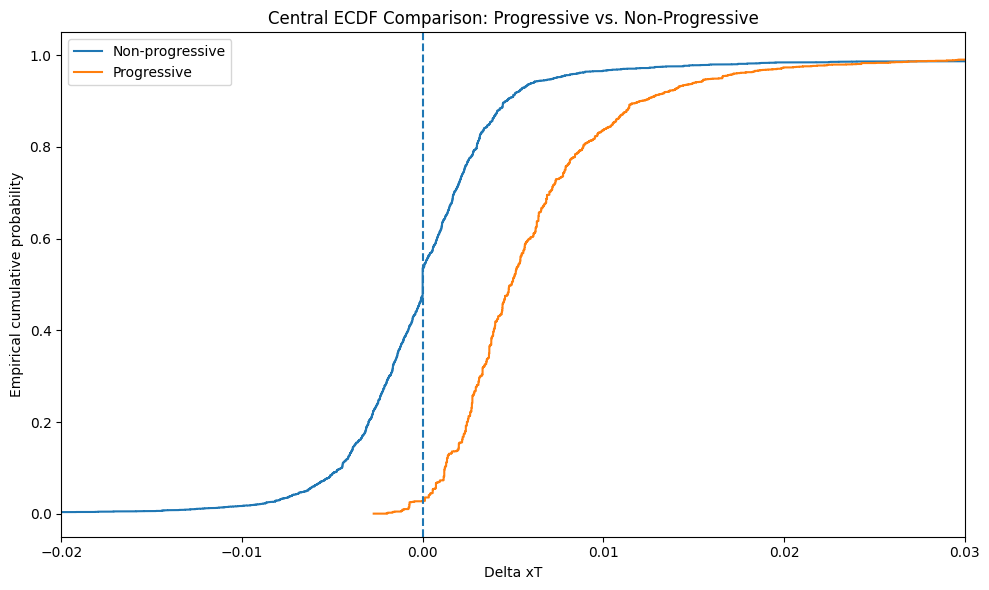

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.step(
    non_progressive_x,
    non_progressive_ecdf,
    where="post",
    label="Non-progressive"
)

ax.step(
    progressive_x,
    progressive_ecdf,
    where="post",
    label="Progressive"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(-0.02, 0.03)

ax.set_title(
    "Central ECDF Comparison: Progressive vs. Non-Progressive"
)

ax.set_xlabel("Delta xT")
ax.set_ylabel("Empirical cumulative probability")

ax.legend()

plt.tight_layout()
plt.show()

#### Distributional Comparison: Progressive vs. Non-Progressive Passes

The ECDF comparison confirms that the difference between progressive and
non-progressive completed passes is not restricted to their sample means.

Around the central part of the distribution, the progressive-pass ECDF lies
clearly below and to the right of the non-progressive-pass ECDF. This indicates
that completed progressive passes are systematically associated with higher
$\Delta xT$ values.

The difference is particularly visible at $\Delta xT = 0$:

- approximately **53.58%** of completed non-progressive passes have
  $\Delta xT \leq 0$,
- compared with only approximately **2.82%** of completed progressive passes.

Thus, almost all completed progressive passes move possession to a state with
higher Expected Threat, whereas more than half of completed non-progressive
passes produce no positive threat change.

Importantly, this pattern is visible across the central distribution and is
therefore not explained only by a small number of extreme high-value
progressive passes.

The ECDFs converge in the upper tail. Therefore, the plots are interpreted as
evidence of a strong distributional shift rather than as proof of strict
stochastic dominance over the entire support.

This comparison still conditions on successful pass completion. Execution risk
is examined separately in the next step.

In [40]:
pass_attempts_df = main_passes_df.copy()

pass_attempts_df["progression_group"] = np.where(
    pass_attempts_df["is_progressive_attempt"],
    "Progressive",
    "Non-progressive"
)

completion_summary = (
    pass_attempts_df
    .groupby("progression_group")
    .agg(
        attempts=("pass_success", "size"),
        completed=("pass_success", "sum"),
        completion_rate=("pass_success", "mean")
    )
)

completion_summary["failed"] = (
    completion_summary["attempts"]
    - completion_summary["completed"]
)

completion_summary["failure_rate"] = (
    1 - completion_summary["completion_rate"]
)

completion_summary["completion_rate_pct"] = (
    completion_summary["completion_rate"] * 100
)

completion_summary["failure_rate_pct"] = (
    completion_summary["failure_rate"] * 100
)

completion_summary

,attempts,completed,completion_rate,failed,failure_rate,completion_rate_pct,failure_rate_pct
progression_group,,,,,,,
Non-progressive,16055,14536,0.905388,1519,0.094612,90.538773,9.461227
Progressive,3342,2412,0.721724,930,0.278276,72.172352,27.827648


#### Interpretation: Completion Risk

The previous analysis showed that completed progressive passes generate
substantially more attacking value than completed non-progressive passes.

However, this comparison considered only passes that were successfully completed.
To evaluate the execution risk of progressive passing, all dynamic-possession
pass attempts are now included.

Progressive passes have a substantially lower completion rate:

- Non-progressive passes: **90.54% completed**
- Progressive passes: **72.17% completed**

Correspondingly, the observed failure rate increases from **9.46%** for
non-progressive passes to **27.83%** for progressive passes.

This reveals an important reward-risk trade-off:

> **Progressive passes generate substantially greater attacking value when
> completed, but they are also considerably more difficult to execute
> successfully.**

Therefore, the higher realized value of progressive passing should not be
interpreted in isolation.

The relevant decision question is not simply whether progressive passes create
more value, but whether their additional attacking reward is sufficient to
compensate for their higher probability of failure.

At this stage, completion failure is treated only as an execution-risk measure.
The potential value or cost of possession after a failed pass is not yet
quantified.

### 4.11 Reward-Risk Baseline

The previous analyses examined two different dimensions of progressive passing:

1. **realized attacking value conditional on successful completion**, and
2. **the probability of successful execution**.

These dimensions are now combined descriptively in a single summary.

The purpose is not yet to calculate a final net value. A failed pass may have
different consequences depending on where and how possession is lost, and these
consequences have not yet been assigned an xT-based cost.

The table therefore provides a **reward-risk baseline**, rather than a final
decision metric.

In [41]:
reward_risk_summary = (
    completion_summary[
        [
            "attempts",
            "completed",
            "failed",
            "completion_rate_pct",
            "failure_rate_pct"
        ]
    ]
    .join(
        progression_distribution_summary[
            [
                "mean_delta_xT",
                "median_delta_xT",
                "Q1",
                "Q3",
                "positive_pct",
                "negative_pct"
            ]
        ],
        how="left"
    )
)

reward_risk_summary

,attempts,completed,failed,completion_rate_pct,failure_rate_pct,mean_delta_xT,median_delta_xT,Q1,Q3,positive_pct,negative_pct
progression_group,,,,,,,,,,,
Non-progressive,16055,14536,1519,90.538773,9.461227,0.001321,0.000000,-0.002383,0.002298,46.415795,47.406439
Progressive,3342,2412,930,72.172352,27.827648,0.006644,0.004917,0.002752,0.007871,97.180763,2.819237


In [42]:
executive_reward_risk_summary = (
    reward_risk_summary[
        [
            "attempts",
            "completion_rate_pct",
            "failure_rate_pct",
            "mean_delta_xT",
            "median_delta_xT",
            "positive_pct"
        ]
    ]
    .copy()
)

executive_reward_risk_summary.columns = [
    "Attempts",
    "Completion Rate (%)",
    "Failure Rate (%)",
    "Mean Delta xT if Completed",
    "Median Delta xT if Completed",
    "Positive Delta xT if Completed (%)"
]

executive_reward_risk_summary.round(4)

,Attempts,Completion Rate (%),Failure Rate (%),Mean Delta xT if Completed,Median Delta xT if Completed,Positive Delta xT if Completed (%)
progression_group,,,,,,
Non-progressive,16055,90.5388,9.4612,0.0013,0.0000,46.4158
Progressive,3342,72.1724,27.8276,0.0066,0.0049,97.1808


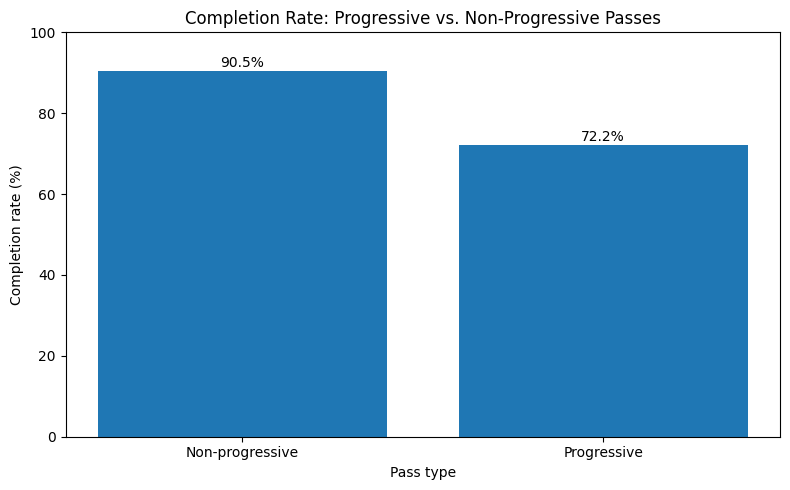

In [43]:
completion_plot_df = (
    completion_summary
    .reset_index()
    .set_index("progression_group")
    .loc[
        ["Non-progressive", "Progressive"]
    ]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    completion_plot_df["progression_group"],
    completion_plot_df["completion_rate_pct"]
)

ax.set_ylim(0, 100)

ax.set_title(
    "Completion Rate: Progressive vs. Non-Progressive Passes"
)

ax.set_xlabel("Pass type")
ax.set_ylabel("Completion rate (%)")

for bar, value in zip(
    bars,
    completion_plot_df["completion_rate_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 5. Match-Level Robustness and Cluster-Aware Uncertainty

The pooled reward-risk pattern may conceal substantial variation across matches.
As a robustness check, the progressive and non-progressive pass profiles are
therefore compared within each of the 34 matches.

This section is not intended to establish a new tactical finding. Its purpose
is to determine whether the pooled baseline is driven by a small number of
unusual matches or is broadly present throughout the sample.

In [44]:
if "match_id" not in completed_main_xt_df.columns:
    raise KeyError(
        "match_id is missing from completed_main_xt_df."
    )

if "match_id" not in pass_attempts_df.columns:
    raise KeyError(
        "match_id is missing from pass_attempts_df."
    )


# Realized attacking value among completed passes
match_value_summary = (
    completed_main_xt_df
    .groupby(
        ["match_id", "progression_group"]
    )
    .agg(
        completed_passes=("delta_xT", "size"),
        mean_delta_xT=("delta_xT", "mean"),
        median_delta_xT=("delta_xT", "median"),
        positive_delta_xT_pct=(
            "delta_xT",
            lambda x: (x > 0).mean() * 100
        )
    )
    .reset_index()
)


# Completion probability among all pass attempts
match_completion_summary = (
    pass_attempts_df
    .groupby(
        ["match_id", "progression_group"]
    )
    .agg(
        attempts=("pass_success", "size"),
        completed=("pass_success", "sum"),
        completion_rate=("pass_success", "mean")
    )
    .reset_index()
)

match_completion_summary["completion_rate_pct"] = (
    match_completion_summary["completion_rate"]
    * 100
)


print(
    "Matches in value analysis:",
    match_value_summary["match_id"].nunique()
)

print(
    "Matches in completion analysis:",
    match_completion_summary["match_id"].nunique()
)

print("\nMatch-level value summary:")
display(match_value_summary.head())

print("\nMatch-level completion summary:")
display(match_completion_summary.head())

Matches in value analysis: 34
Matches in completion analysis: 34

Match-level value summary:


,match_id,progression_group,completed_passes,mean_delta_xT,median_delta_xT,positive_delta_xT_pct
0,3895052,Non-progressive,372,0.003583,-0.000161,43.279570
1,3895052,Progressive,73,0.005508,0.004563,97.260274
2,3895060,Non-progressive,502,0.002050,0.000000,48.804781
3,3895060,Progressive,83,0.007549,0.005655,96.385542
4,3895067,Non-progressive,383,0.000942,0.000000,49.086162



Match-level completion summary:


,match_id,progression_group,attempts,completed,completion_rate,completion_rate_pct
0,3895052,Non-progressive,425,372,0.875294,87.529412
1,3895052,Progressive,103,73,0.708738,70.873786
2,3895060,Non-progressive,543,502,0.924494,92.449355
3,3895060,Progressive,113,83,0.734513,73.451327
4,3895067,Non-progressive,425,383,0.901176,90.117647


### 5.1 Within-Match Reward-Risk Comparison

The pooled analysis showed that progressive passes provide greater realized
attacking value when completed, but have a lower probability of successful
completion.

The next step examines whether this pattern is also visible within individual
matches.

For each match, the following differences are calculated:

$$
D_m^{value}
=
\overline{\Delta xT}_{m,\mathrm{Progressive}}
-
\overline{\Delta xT}_{m,\mathrm{Non\text{-}progressive}}
$$

and

$$
D_m^{completion}
=
CompletionRate_{m,\mathrm{Progressive}}
-
CompletionRate_{m,\mathrm{Non\text{-}progressive}}.
$$

Therefore:

- $D_m^{value} > 0$ means that completed progressive passes generated greater
  average attacking value within match $m$.
- $D_m^{completion} < 0$ means that progressive passes had a lower completion
  rate within match $m$.

This paired match-level comparison helps determine whether the pooled
reward-risk pattern is broadly consistent across matches or driven primarily
by a small number of games.

In [45]:
match_value_wide = (
    match_value_summary
    .pivot(
        index="match_id",
        columns="progression_group",
        values="mean_delta_xT"
    )
)

match_completion_wide = (
    match_completion_summary
    .pivot(
        index="match_id",
        columns="progression_group",
        values="completion_rate_pct"
    )
)

match_comparison = pd.DataFrame({
    "progressive_mean_delta_xT":
        match_value_wide["Progressive"],

    "non_progressive_mean_delta_xT":
        match_value_wide["Non-progressive"],

    "progressive_completion_rate_pct":
        match_completion_wide["Progressive"],

    "non_progressive_completion_rate_pct":
        match_completion_wide["Non-progressive"]
})

match_comparison[
    "value_difference"
] = (
    match_comparison["progressive_mean_delta_xT"]
    - match_comparison["non_progressive_mean_delta_xT"]
)

match_comparison[
    "completion_difference_pct"
] = (
    match_comparison["progressive_completion_rate_pct"]
    - match_comparison["non_progressive_completion_rate_pct"]
)

match_comparison.head()

,progressive_mean_delta_xT,non_progressive_mean_delta_xT,progressive_completion_rate_pct,non_progressive_completion_rate_pct,value_difference,completion_difference_pct
match_id,,,,,,
3895052,0.005508,0.003583,70.873786,87.529412,0.001925,-16.655625
3895060,0.007549,0.002050,73.451327,92.449355,0.005499,-18.998028
3895067,0.006108,0.000942,70.093458,90.117647,0.005166,-20.024189
3895074,0.008622,0.000110,80.392157,89.857651,0.008512,-9.465494
3895086,0.006360,0.000599,78.095238,91.956124,0.005761,-13.860886


In [46]:
n_matches = len(match_comparison)

matches_higher_progressive_value = (
    match_comparison["value_difference"] > 0
).sum()

matches_lower_progressive_completion = (
    match_comparison["completion_difference_pct"] < 0
).sum()

match_consistency_summary = pd.DataFrame({
    "quantity": [
        "Matches compared",
        "Matches with higher progressive mean Delta xT",
        "Percentage with higher progressive mean Delta xT",
        "Matches with lower progressive completion rate",
        "Percentage with lower progressive completion rate",
        "Median within-match Delta xT difference",
        "Median within-match completion-rate difference (pp)"
    ],
    "value": [
        n_matches,
        matches_higher_progressive_value,
        matches_higher_progressive_value / n_matches * 100,
        matches_lower_progressive_completion,
        matches_lower_progressive_completion / n_matches * 100,
        match_comparison["value_difference"].median(),
        match_comparison["completion_difference_pct"].median()
    ]
})

match_consistency_summary

,quantity,value
0,Matches compared,34.000000
1,Matches with higher progressive mean Delta xT,34.000000
2,Percentage with higher progressive mean Delta xT,100.000000
3,Matches with lower progressive completion rate,34.000000
4,Percentage with lower progressive completion rate,100.000000
5,Median within-match Delta xT difference,0.005166
6,Median within-match completion-rate difference...,-17.915181


### Interpretation

The pooled reward-risk pattern is present in every match in the sample.

Across all 34 matches:

- completed progressive passes had a higher mean $\Delta xT$ than completed
  non-progressive passes in **34 of 34 matches**;
- progressive pass attempts had a lower completion rate in **34 of 34 matches**.

The median within-match difference in mean attacking value was approximately

$$
+0.00517 \; \Delta xT,
$$

while the median completion-rate difference was approximately

$$
-17.92
$$

percentage points.

This indicates that the pooled reward-risk pattern is not driven by a small
number of exceptional matches.

However, this result remains a **baseline robustness finding rather than a
tactical conclusion**. Progression is defined spatially and is therefore
structurally related to movement toward higher-value xT states.

The analytically more important question is therefore not whether progressive
passes tend to create more value, but **which types of progressive passes create
the most value, under which tactical conditions, and at what execution risk**.

### 5.2 Cluster-Aware Uncertainty

The previous analysis showed that pass observations are grouped within matches.
Passes from the same match share opponent, tactical, game-state, and contextual
conditions and should therefore not automatically be treated as independent
observations.

The next step quantifies uncertainty while preserving this dependence structure.

A match-cluster bootstrap is used:

1. the 34 matches are sampled with replacement;
2. all pass observations belonging to each sampled match are retained;
3. the reward and completion differences are recalculated;
4. the procedure is repeated many times.

Two quantities are considered:

$$
\Delta_{\text{reward}}
=
\overline{\Delta xT}_{\text{Progressive}}
-
\overline{\Delta xT}_{\text{Non-progressive}},
$$

among completed passes, and

$$
\Delta_{\text{completion}}
=
P(\text{completion}\mid\text{Progressive})
-
P(\text{completion}\mid\text{Non-progressive}),
$$

among all pass attempts.

The bootstrap therefore provides uncertainty intervals for the two dimensions
of the reward-risk baseline without imposing a Normal distribution on the raw
pass-level $\Delta xT$ observations.

In [47]:
rng = np.random.default_rng(42)

match_ids = completed_main_xt_df["match_id"].unique()

N_BOOTSTRAP = 2000

bootstrap_reward_difference = np.empty(N_BOOTSTRAP)
bootstrap_completion_difference = np.empty(N_BOOTSTRAP)


# Pre-split the datasets by match
completed_by_match = {
    match_id: group
    for match_id, group in completed_main_xt_df.groupby("match_id")
}

attempts_by_match = {
    match_id: group
    for match_id, group in pass_attempts_df.groupby("match_id")
}


for b in range(N_BOOTSTRAP):

    sampled_match_ids = rng.choice(
        match_ids,
        size=len(match_ids),
        replace=True
    )

    # Keep complete match clusters
    completed_bootstrap = pd.concat(
        [
            completed_by_match[match_id]
            for match_id in sampled_match_ids
        ],
        ignore_index=True
    )

    attempts_bootstrap = pd.concat(
        [
            attempts_by_match[match_id]
            for match_id in sampled_match_ids
        ],
        ignore_index=True
    )

    # Reward difference among completed passes
    reward_means = (
        completed_bootstrap
        .groupby("progression_group")["delta_xT"]
        .mean()
    )

    bootstrap_reward_difference[b] = (
        reward_means["Progressive"]
        - reward_means["Non-progressive"]
    )

    # Completion-rate difference among all attempts
    completion_rates = (
        attempts_bootstrap
        .groupby("progression_group")["pass_success"]
        .mean()
    )

    bootstrap_completion_difference[b] = (
        completion_rates["Progressive"]
        - completion_rates["Non-progressive"]
    ) * 100

In [48]:
observed_reward_difference = (
    completed_main_xt_df.loc[
        completed_main_xt_df["progression_group"] == "Progressive",
        "delta_xT"
    ].mean()
    -
    completed_main_xt_df.loc[
        completed_main_xt_df["progression_group"] == "Non-progressive",
        "delta_xT"
    ].mean()
)

observed_completion_difference = (
    pass_attempts_df.loc[
        pass_attempts_df["progression_group"] == "Progressive",
        "pass_success"
    ].mean()
    -
    pass_attempts_df.loc[
        pass_attempts_df["progression_group"] == "Non-progressive",
        "pass_success"
    ].mean()
) * 100


reward_ci = np.quantile(
    bootstrap_reward_difference,
    [0.025, 0.975]
)

completion_ci = np.quantile(
    bootstrap_completion_difference,
    [0.025, 0.975]
)


cluster_bootstrap_summary = pd.DataFrame({
    "quantity": [
        "Observed reward difference",
        "Reward difference 95% CI lower",
        "Reward difference 95% CI upper",
        "Observed completion-rate difference (pp)",
        "Completion difference 95% CI lower (pp)",
        "Completion difference 95% CI upper (pp)"
    ],
    "value": [
        observed_reward_difference,
        reward_ci[0],
        reward_ci[1],
        observed_completion_difference,
        completion_ci[0],
        completion_ci[1]
    ]
})

cluster_bootstrap_summary

,quantity,value
0,Observed reward difference,0.005323
1,Reward difference 95% CI lower,0.004756
2,Reward difference 95% CI upper,0.005836
3,Observed completion-rate difference (pp),-18.366421
4,Completion difference 95% CI lower (pp),-20.174687
5,Completion difference 95% CI upper (pp),-16.583055


#### Interpretation of Cluster-Bootstrap Uncertainty

The observed reward contrast is

$$
\widehat{\Delta}_{\mathrm{reward}}
=
0.005323,
$$

with a 95% match-cluster percentile bootstrap interval of

$$
[0.004756,\;0.005836].
$$

The observed completion-rate contrast is

$$
\widehat{\Delta}_{\mathrm{completion}}
=
-18.37
$$

percentage points, with a corresponding bootstrap interval of

$$
[-20.17,\;-16.58].
$$

Across the match-cluster bootstrap resamples, the estimated reward difference
remains positive, while the estimated completion-rate difference remains
negative.

The bootstrap does not replace the original estimators. In every bootstrap
sample, the same pass-weighted mean difference and completion-proportion
difference are recalculated.

Its purpose is to approximate the sampling variability of these estimators
while preserving the dependence of pass observations within matches.

The intervals therefore quantify uncertainty with respect to resampling the
34 observed match clusters.

They should not be interpreted as establishing league-wide population effects.
The available matches are not treated as a random representative sample of the
entire Bundesliga population, and the relationship between progression and
xT is partly structural because both measures depend on spatial advancement.

## 6. Statistical Implications and Handoff

This notebook established the statistical baseline required for the subsequent
tactical analysis.

The empirical distribution of pass-level $\Delta xT$ is strongly asymmetric
and highly concentrated around zero. No simple parametric distribution was
therefore imposed on the raw observations. Expected attacking reward was
defined explicitly as a distributional estimand and estimated using the
pass-weighted sample mean, while the median, quantiles and ECDF were retained
to describe aspects of the distribution that the mean alone cannot capture.

Execution risk was analysed separately through the empirical pass-completion
probability.

Because pass observations are clustered within matches, uncertainty for the
primary reward and completion contrasts was quantified using a match-cluster
bootstrap rather than treating all pass events as independent sampling units.

The resulting baseline shows a consistent pattern in the analysed sample:
progressive passes generate greater realised attacking value when completed,
but they also have a substantially lower probability of successful execution.

This aggregate comparison is intentionally treated as a baseline rather than
as the final tactical result.

Progression and xT are both related to spatial advancement, so the observed
difference between progressive and non-progressive passes is partly structural.
In addition, the current analysis does not assign a value to the consequences
of a failed pass and therefore does not yet provide a net-value decision metric.

The next analytical step is consequently not another aggregate comparison.
Instead, progressive actions must be decomposed into tactically meaningful
types to determine whether the broad progressive-pass category hides important
differences in attacking reward and execution reliability.

This motivates the tactical segmentation developed in Notebook 03.

## 7. Executive Takeaways

### Decision Summary

The baseline analysis identifies a clear trade-off in progressive passing.

Within the analysed 34-match sample, progressive passes create substantially
greater attacking value when they are successfully completed, but their
completion probability is considerably lower.

The aggregate progressive-pass KPI therefore captures an important performance
dimension, but it is not sufficiently granular to support tactical decisions
on its own.

| Business question | Evidence from the analysis | Decision implication |
| --- | --- | --- |
| Does successful progression create additional attacking value? | Completed progressive passes produced mean $\Delta xT$ of approximately **0.00664**, compared with **0.00132** for non-progressive passes. The estimated difference is **+0.00532**. | Progression is associated with materially greater realised attacking value when execution succeeds. |
| Is the value difference driven only by a few exceptional actions? | The progressive-pass median is approximately **0.00492**, and **97.2%** of completed progressive passes have positive $\Delta xT$. | The value advantage is visible across the central distribution and is not explained only by a small upper tail. |
| What is the execution cost? | Progressive-pass completion is approximately **72.2%**, compared with **90.5%** for non-progressive passes: a difference of **−18.37 percentage points**. | Reward cannot be evaluated independently of execution reliability. |
| Is the aggregate pattern dependent on only a few matches? | The same reward-risk direction appears in **34 of 34 matches**. Match-cluster bootstrap intervals are **[0.00476, 0.00584]** for the reward difference and **[−20.17, −16.58] percentage points** for the completion difference. | The baseline pattern is stable within the analysed match sample and provides a reasonable foundation for deeper segmentation. |

### Business Intelligence Interpretation

The main limitation of the aggregate KPI is now clear.

“Progressive pass” combines actions that may differ substantially in their
destination, geometry, tactical purpose and execution difficulty. An aggregate
average can therefore hide meaningful differences between types of progression.

The analysis also deliberately keeps reward and execution risk separate.
A failed pass is currently represented through its completion outcome, but the
subsequent cost of losing the action has not yet been assigned an attacking or
defensive value.

For this reason, the current results should not be converted into a single
“net progressive-pass value” score.

### Decision Question for the Next Stage

The next analysis moves from an aggregate KPI to tactical segmentation.

The relevant question becomes:

> **How do different types of progressive passing differ in realised attacking
> value, execution reliability and usage frequency?**

Notebook 03 will therefore define progression using tactical and geometric
characteristics such as destination zones and movement patterns.

These route definitions will initially be based on pass geometry rather than
on $\Delta xT$ itself. This avoids defining a category by the same outcome
measure that is subsequently used to evaluate it.

Because tactical characteristics may overlap — for example, a pass may enter
both the final third and the box — the first step will be to examine overlap
between route definitions before constructing the final reporting
segmentation.

### Scope

The results describe the available 34-match sample.

They are not interpreted as causal effects or as representative league-wide
Bundesliga estimates. In addition, progression and xT both depend on spatial
advancement, so the progressive-versus-non-progressive comparison is used as a
baseline rather than as the final tactical conclusion.

In [49]:
# ---------------------------------------------------------
# Outputs for downstream tactical analysis
# ---------------------------------------------------------

# All dynamic-possession pass attempts:
# required for route frequencies and completion-risk analysis
pass_attempts_df.to_csv(
    PROCESSED_DIR / "pass_attempts_for_tactical_analysis.csv",
    index=False
)

# Completed passes with realized xT values:
# required for attacking-value analysis
completed_main_xt_df.to_csv(
    PROCESSED_DIR / "completed_passes_with_xt.csv",
    index=False
)

# Final estimated xT surface
final_xt_df.to_csv(
    PROCESSED_DIR / "xt_state_values.csv",
    index=False
)

# Aggregate reward-risk baseline
reward_risk_summary.reset_index().to_csv(
    PROCESSED_DIR / "progression_reward_risk_summary.csv",
    index=False
)

# Match-level robustness results
match_comparison.reset_index().to_csv(
    PROCESSED_DIR / "progression_match_comparison.csv",
    index=False
)

# Cluster-bootstrap uncertainty summary
cluster_bootstrap_summary.to_csv(
    PROCESSED_DIR / "cluster_bootstrap_summary.csv",
    index=False
)

print("Notebook 02 outputs saved successfully.")
print("Data required for Notebook 03 are ready.")

Notebook 02 outputs saved successfully.
Data required for Notebook 03 are ready.
